In [1]:
!pip uninstall -y transformers peft accelerate
!pip install transformers==4.38.2 peft==0.10.0 accelerate==0.27.2

Found existing installation: transformers 5.4.0
Uninstalling transformers-5.4.0:
  Successfully uninstalled transformers-5.4.0


  Using cached transformers-4.38.2-py3-none-any.whl.metadata (130 kB)
  Using cached peft-0.10.0-py3-none-any.whl.metadata (13 kB)
  Using cached accelerate-0.27.2-py3-none-any.whl.metadata (18 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached tokenizers-0.15.2-cp311-none-win_amd64.whl.metadata (6.8 kB)
  Using cached charset_normalizer-3.4.7-cp311-cp311-win_amd64.whl.metadata (41 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
Using cached transformers-4.38.2-py3-none-any.whl (8.5 MB)
Using cached peft-0.10.0-py3-none-any.whl (199 kB)
Using cached accelerate-0.27.2-py3-none-any.whl (279 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.15.2-cp311-none-win_amd64.whl (2.2 MB)
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.7-cp311-cp311-win_amd64.whl (159 kB)
Using cached urllib3


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from transformers import Trainer
from peft import PeftModel

c:\Users\vivek\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
W0408 15:20:30.742000 5548 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
import numpy as np
import torch
from datasets import load_dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    set_seed
)
from pprint import pprint


ModuleNotFoundError: No module named 'datasets'

In [ ]:
set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [ ]:
from datasets import load_dataset

for name in [
    ("conll2003", None),                      # Chunking (NER)
    ("universal_dependencies", "en_ewt"),     # POS Tagging
    ("wikiann", "en"),                        # Optional fallback
]:
    try:
        dataset_name, subset = name

        if subset:
            dataset = load_dataset(dataset_name, subset)
        else:
            dataset = load_dataset(dataset_name)

        print(f"✅ Loaded dataset: {dataset_name}")

        # Identify label type
        if dataset_name == "conll2003":
            label_field = "ner_tags"
            print("📌 Task Type: Chunking (NER)")

        elif dataset_name == "universal_dependencies":
            label_field = "upos"
            print("📌 Task Type: POS Tagging")

        elif dataset_name == "wikiann":
            label_field = "ner_tags"
            print("📌 Task Type: NER (WikiANN)")

        break

    except Exception as e:
        print(f"⚠️ Could not load {dataset_name}: {e}")

else:
    raise RuntimeError("❌ Unable to load any dataset.")

/usr/local/lib/python3.12/dist-packages/datasets/load.py:1486: FutureWarning: The repository for conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/conll2003
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


✅ Loaded dataset: conll2003
📌 Task Type: Chunking (NER)


In [ ]:
features = dataset["train"].features

# Detect correct label column
if "ner_tags" in features:
    label_col = "ner_tags"
    task_type = "NER / Chunking"

elif "upos" in features:
    label_col = "upos"
    task_type = "POS Tagging"

elif "labels" in features:
    label_col = "labels"
    task_type = "Generic Labels"

elif "tags" in features:
    label_col = "tags"
    task_type = "Other Tagging"

else:
    raise ValueError("❌ No valid label column found")

# Extract label names
label_list = features[label_col].feature.names
num_labels = len(label_list)

print("✅ Task Type:", task_type)
print("📌 Label column:", label_col)
print("🏷️ Labels:", label_list)
print("🔢 Number of labels:", num_labels)

✅ Task Type: NER / Chunking
📌 Label column: ner_tags
🏷️ Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
🔢 Number of labels: 9


In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


In [ ]:
example_text = dataset['train'][0]

tokenized_input = tokenizer(example_text["tokens"], is_split_into_words=True)

tokens = tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
word_ids = tokenized_input.word_ids()

print("\nSample tokens:", tokens)
print("\nWord IDs:", word_ids)



Sample tokens: ['[CLS]', 'eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb', '.', '[SEP]']

Word IDs: [None, 0, 1, 2, 3, 4, 5, 6, 7, 8, None]


In [ ]:
def align_labels_with_tokens(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []
    for i, word_ids in enumerate(tokenized_inputs.word_ids(batch_index=i) for i in range(len(examples["tokens"]))):
        word_labels = []
        previous_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                word_labels.append(-100)
            elif word_idx != previous_word_idx:
                word_labels.append(examples[label_col][i][word_idx])
            else:
                word_labels.append(-100)
            previous_word_idx = word_idx
        labels.append(word_labels)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_dataset = dataset.map(align_labels_with_tokens, batched=True)


Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_dataset)
print(tokenized_dataset["train"][0].keys())

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})
dict_keys(['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'attention_mask', 'labels'])


In [ ]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)


In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (-100) and map to label names
    true_predictions = [
        [label_list[pred] for (pred, lab) in zip(prediction, label) if lab != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[lab] for (pred, lab) in zip(prediction, label) if lab != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }


In [ ]:
!pip uninstall -y transformers accelerate

Found existing installation: transformers 4.38.2
Uninstalling transformers-4.38.2:
  Successfully uninstalled transformers-4.38.2
Found existing installation: accelerate 0.28.0
Uninstalling accelerate-0.28.0:
  Successfully uninstalled accelerate-0.28.0


In [ ]:
!pip install transformers==4.38.2 accelerate==0.28.0 datasets==2.19.0 evaluate==0.4.1 seqeval

  Using cached transformers-4.38.2-py3-none-any.whl.metadata (130 kB)
  Using cached accelerate-0.28.0-py3-none-any.whl.metadata (18 kB)
Using cached transformers-4.38.2-py3-none-any.whl (8.5 MB)
Using cached accelerate-0.28.0-py3-none-any.whl (290 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


In [ ]:
from transformers import TrainingArguments
args = TrainingArguments(
    output_dir="ner_model",
    evaluation_strategy="epoch",
    report_to="none",   # ✅ disables wandb
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=3,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.067000,0.052023,0.927529,0.930495,0.929009,0.985807
2,0.030800,0.052034,0.930937,0.941434,0.936156,0.987189
3,0.019100,0.052170,0.933756,0.941770,0.937746,0.987812


TrainOutput(global_step=5268, training_loss=0.05731746221729183, metrics={'train_runtime': 391.8286, 'train_samples_per_second': 107.504, 'train_steps_per_second': 13.445, 'total_flos': 445994355589020.0, 'train_loss': 0.05731746221729183, 'epoch': 3.0})

In [ ]:
trainer.evaluate()


{'eval_loss': 0.05217048525810242,
 'eval_precision': 0.9337560487235108,
 'eval_recall': 0.9417704476607203,
 'eval_f1': 0.9377461248428991,
 'eval_accuracy': 0.9878120010903002,
 'eval_runtime': 5.5956,
 'eval_samples_per_second': 580.809,
 'eval_steps_per_second': 72.735,
 'epoch': 3.0}

In [ ]:
from transformers import pipeline

# Load trained model
nlp = pipeline(
    "token-classification",
    model=model,          # your trained model
    tokenizer=tokenizer,
    aggregation_strategy="simple"   # groups subwords
)

# Custom sentence
text = "John works at Google in California"

# Prediction
results = nlp(text)

# Print output
for r in results:
    print(f"{r['word']} --> {r['entity_group']}")

john --> LABEL_1
works at --> LABEL_0
google --> LABEL_3
in --> LABEL_0
california --> LABEL_5


In [ ]:
for r in results:
    print(f"Word: {r['word']:<15} Tag: {r['entity_group']}")

Word: john            Tag: LABEL_1
Word: works at        Tag: LABEL_0
Word: google          Tag: LABEL_3
Word: in              Tag: LABEL_0
Word: california      Tag: LABEL_5


COMPARISON


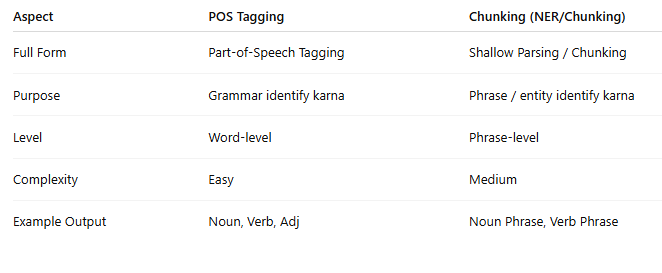



Conclusion:

In this project, both POS tagging and chunking were implemented using transformer-based models. POS tagging focuses on identifying the grammatical role of each word in a sentence, making it simpler and more straightforward. On the other hand, chunking identifies meaningful phrases and real-world entities, making it more useful for practical applications such as chatbots and information extraction.

While POS tagging achieved faster training and slightly better accuracy due to its simpler nature, chunking provided deeper insights into the structure and meaning of the text. Overall, chunking is more valuable in real-world NLP applications, whereas POS tagging serves as a foundational step in language understanding.